# 第 11 天：私有世界泛化

比较 public-test 表现和 private-eval 表现，诊断策略是否过拟合。

今天关注泛化：一个策略在公开世界上高分，不代表它学到了可迁移的化学规律。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | D. 接近科研评测 |
| 难度 | 挑战 4/4 |
| 先修 | 已理解 public-test 提交流程。 |
| 今天只解决 | 诊断 public/private gap，区分稳健策略和公开世界过拟合。 |
| 今天不要求 | 不尝试反推 hidden parameters，也不把 private split 当训练集。 |
| 本日交付 | 泛化差距表、失败模式分析、下一版策略修正。 |
| 下一步如何复用 | Day 12 会把泛化、机理、复现性整合进最终展示。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 区分 public/private | 读取 split 设计和 hidden salt 思路。 | 说明什么是过拟合。 |
| 0:30-1:00 | 运行 public-test | 用固定策略获得 public 结果。 | 得到 public 指标。 |
| 1:00-1:30 | 运行 private-eval | 在隐藏参数 split 上重跑。 | 得到 private 指标。 |
| 1:30-2:00 | 计算 gap | 比较均值、方差和 public-private gap。 | 得到泛化表。 |
| 2:00-2:30 | 诊断失败原因 | 判断是安全、成本、机制还是搜索空间过拟合。 | 写失败诊断。 |
| 2:30-3:00 | 改进策略 | 提出更稳健的探索或安全约束。 | 得到下一版计划。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 比较同一策略在两个 split 上的表现差异。 |
| 进阶任务 | 把差异拆成 performance、safety、sample efficiency 和 invalid action。 |
| 挑战任务 | 提出一个更稳健的探索策略并说明它如何降低 gap。 |
| 反思问题 | 一个策略在 hidden world 上变差，可能是机理误判、采样不足，还是过拟合？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 至少比较 2 个策略在 public-test 与 private-like split 上的表现。 |
| 2 | 每个策略至少 3 个 seed，报告均值、标准误和 public/private gap。 |
| 3 | 把 gap 拆成 performance、safety、sample efficiency、invalid operation 四部分。 |
| 4 | 写 500 字泛化诊断：失败来自机理误判、采样不足、噪声，还是公开榜过拟合。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(11)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day11


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


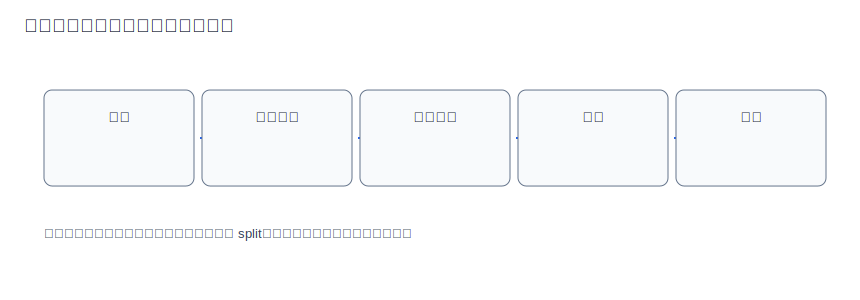

In [2]:
tu.display_tutorial_header(
    day=11,
    title='私有世界泛化',
    subtitle='比较 public-test 表现和 private-eval 表现，诊断策略是否过拟合。',
    focus=[
        'private-eval split',
        'generalization gap',
        'overfitting diagnosis',
        'robust strategy',
    ],
    deliverables=[
        '一张 public/private gap 表',
        '一张泛化差距图',
        '一段过拟合诊断',
    ],
    project_link='真正的 leaderboard 要用 hidden worlds 检查 public 策略是否能迁移。',
)
tu.display_course_map(11)
display(tu.world_law_svg())


In [3]:
tu.display_api_card()

## 第 11 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张 public/private 对比表
- 一张 gap 图
- 一段过拟合诊断


In [5]:
from chemworld.eval.metrics import evaluate_records

strategies = {
    "public_best": {
        "temperature": 75.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "robust_low_risk": {
        "temperature": 65.0,
        "time": 0.75,
        "initial_concentration": 0.25,
        "stirring_speed": 600.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "fast_high_heat": {
        "temperature": 115.0,
        "time": 0.30,
        "initial_concentration": 0.45,
        "stirring_speed": 850.0,
        "catalyst": 3,
        "solvent": 2,
    },
}
rows = []
for name, recipe in strategies.items():
    for split in ["public-test", "private-eval"]:
        for seed in range(5):
            records = tu.write_recipe_trajectory(
                recipe,
                OUTPUT_DIR / f"{name}_{split}_seed{seed}.jsonl",
                split=split,
                seed=seed,
                agent_name=f"generalization_{name}",
            )
            result = evaluate_records(records).to_dict()
            rows.append({"strategy": name, "split": split, "seed": seed, **result})
gen_df = pd.DataFrame(rows)
summary = gen_df.groupby(["strategy", "split"], as_index=False).agg(
    mean_total=("total_score", "mean"),
    std_total=("total_score", "std"),
    mean_risk=("mean_safety_risk", "mean"),
)
display(summary)

,strategy,split,mean_total,std_total,mean_risk
0,fast_high_heat,private-eval,0.3110,0.1189,0.1336
1,fast_high_heat,public-test,0.1963,0.1167,0.1339
2,public_best,private-eval,0.3329,0.0561,0.0782
3,public_best,public-test,0.3855,0.0759,0.0781
4,robust_low_risk,private-eval,0.3435,0.0577,0.0704
5,robust_low_risk,public-test,0.3941,0.0803,0.0704


split,strategy,private-eval,public-test,public_private_gap
0,robust_low_risk,0.3435,0.3941,0.0506
1,public_best,0.3329,0.3855,0.0526
2,fast_high_heat,0.3110,0.1963,-0.1147


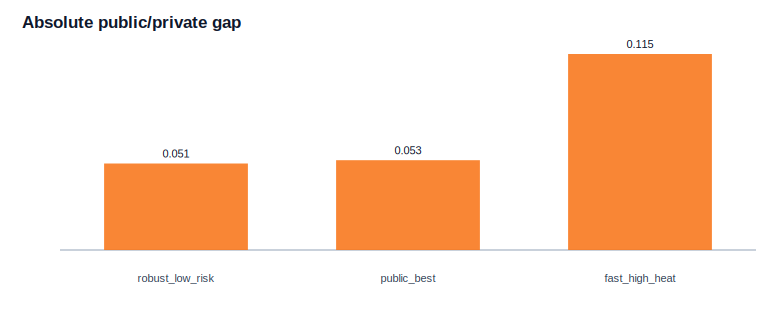

In [6]:
wide = summary.pivot(index="strategy", columns="split", values="mean_total").reset_index()
wide["public_private_gap"] = wide["public-test"] - wide["private-eval"]
wide = wide.sort_values("private-eval", ascending=False).reset_index(drop=True)
display(wide)
display(
    tu.bar_svg(
        wide["strategy"].tolist(),
        wide["public_private_gap"].astype(float).abs().tolist(),
        title="Absolute public/private gap",
        color="#f97316",
    )
)

In [7]:
diagnosis = {
    "small_gap": "Likely robust within this mechanism family.",
    "large_positive_gap": "May be overfit to public-test conditions.",
    "large_negative_gap": "Private placeholder happened to be easier; do not overclaim.",
    "recommended_next_step": ("Trade a little public score for lower risk and lower variance."),
}
tu.show_json_panel("Generalization diagnosis guide", diagnosis)

## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [8]:
tu.display_reflection_box(
    [
        'gap 变大通常说明了什么？',
        '哪些信息必须留到 private eval 才能公开？',
    ]
)
